Число вершин  8
Число ребер  7
Степени вершин  [1 2 2 2 1 2 2 2]


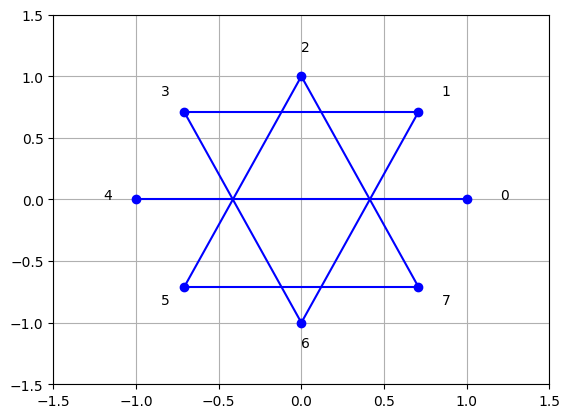

In [4]:
import numpy as np
import matplotlib.pyplot as plt
matrix = [
    [0, 0, 0, 0, 1, 0, 0, 0],
    [0, 0, 0, 1, 0, 0, 1, 0],
    [0, 0, 0, 0, 0, 1, 0, 1],
    [0, 1, 0, 0, 0, 0, 1, 0],
    [1, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 0, 0, 0, 0, 1],
    [0, 1, 0, 1, 0, 0, 0, 0],
    [0, 0, 1, 0, 0, 1, 0, 0]
]

nodes = []
for i in range(len(matrix)):
    neighbors = []
    for j in range(len(matrix[i])):
        if matrix[i][j] == 1:
            neighbors.append(j)
    nodes.append(neighbors)


N = len(nodes)
print('Число вершин ',N)

edges = []
for node_id, adjacent_nodes in enumerate(nodes):
  for adjacent_node in adjacent_nodes:
    q = [node_id, adjacent_node]
    q.sort()
    if q not in edges:
      edges.append(q)

M = len(edges)
print('Число ребер ',M)

S = np.zeros(N,dtype=int)
for node_id, adjacent_nodes in enumerate(nodes):
  S[node_id] = len(adjacent_nodes)
print('Степени вершин ', S)

# Рассчитываем координаты всех вершин
x = np.zeros(N)
y = np.zeros(N)
for k in range(N):
  x[k] = np.cos(2*np.pi*k/N)
  y[k] = np.sin(2*np.pi*k/N)

# Чертим вершины
plt.figure(1)
plt.plot(x,y,'bo')
plt.grid()
plt.xlim([-1.5,1.5])
plt.ylim([-1.5,1.5])

# Подписываем вершины
for k in range(N):
  plt.text(x[k]*1.2,y[k]*1.2,str(k))

# Чертим рёбра (используем список рёбер)
for v in range(M):
  v_1 = edges[v][0]  # Номер вершины начала ребра
  v_2 = edges[v][1]  # Номер вершины конца ребра
  x1 = x[v_1]; y1 = y[v_1]
  x2 = x[v_2]; y2 = y[v_2]
  # Чертим прямую
  plt.plot([x1,x2],[y1,y2], 'b')
 


In [5]:
# Матрица инцидентности 
incidence_matrix = np.zeros((N, M), dtype=int)

for edge_id, (node_1, node_2) in enumerate(edges):
    incidence_matrix[node_1, edge_id] = 1
    incidence_matrix[node_2, edge_id] = 1

print("Ребра:    ", list(range(M)))
for i in range(N):
    print(f"Вершина {i}: {incidence_matrix[i].tolist()}")

Ребра:     [0, 1, 2, 3, 4, 5, 6]
Вершина 0: [1, 0, 0, 0, 0, 0, 0]
Вершина 1: [0, 1, 1, 0, 0, 0, 0]
Вершина 2: [0, 0, 0, 1, 1, 0, 0]
Вершина 3: [0, 1, 0, 0, 0, 1, 0]
Вершина 4: [1, 0, 0, 0, 0, 0, 0]
Вершина 5: [0, 0, 0, 1, 0, 0, 1]
Вершина 6: [0, 0, 1, 0, 0, 1, 0]
Вершина 7: [0, 0, 0, 0, 1, 0, 1]


In [6]:
# Число компонент связности

# Алгоритм обхода в глубину
def deep_search(curr_v, sp_v, Z):
  for k in Z[curr_v]:
    if k not in sp_v:
      sp_v.append(k)
      deep_search(k,sp_v,Z)

sp_comp = []
for k in range(N):
  spv = [k]
  deep_search(k,spv,nodes)
  spv.sort()
  if spv not in sp_comp:
    sp_comp.append(spv)

print('Список компонент связности ', sp_comp)
print('Число компонент связности графа ', len(sp_comp))

Список компонент связности  [[0, 4], [1, 3, 6], [2, 5, 7]]
Число компонент связности графа  3


In [7]:
 # Матрица смежности

adj_matrix = np.zeros((N, N), dtype=int)
for node_id, adjacent_nodes in enumerate(nodes):
    for adjacent_node in adjacent_nodes:
        adj_matrix[node_id, adjacent_node] = 1

print("Вершины:  ", list(range(N)))
for i in range(N):
    print(f"Вершина {i}: {adj_matrix[i].tolist()}")

Вершины:   [0, 1, 2, 3, 4, 5, 6, 7]
Вершина 0: [0, 0, 0, 0, 1, 0, 0, 0]
Вершина 1: [0, 0, 0, 1, 0, 0, 1, 0]
Вершина 2: [0, 0, 0, 0, 0, 1, 0, 1]
Вершина 3: [0, 1, 0, 0, 0, 0, 1, 0]
Вершина 4: [1, 0, 0, 0, 0, 0, 0, 0]
Вершина 5: [0, 0, 1, 0, 0, 0, 0, 1]
Вершина 6: [0, 1, 0, 1, 0, 0, 0, 0]
Вершина 7: [0, 0, 1, 0, 0, 1, 0, 0]
